# Regresja Logistyczna


W niniejszym etapie analizy zastosowano regresję logistyczną do bezpośredniego modelowania wyniku meczu piłkarskiego w postaci trzech klas: zwycięstwo gospodarzy (H – Home win), remis (D – Draw) oraz zwycięstwo gości (A – Away win). Zmienną docelową modelu jest oficjalny wynik meczu oznaczony w zbiorze danych jako FTR (Full Time Result), przyjmujący jedną z trzech powyższych wartości.

Problem ten ma charakter klasyfikacji wieloklasowej i został rozwiązany przy użyciu regresji logistycznej w wariancie multinomialnym, która umożliwia jednoczesną estymację prawdopodobieństw przynależności obserwacji do każdej z klas H, D oraz A. Model zakłada liniową zależność pomiędzy cechami wejściowymi a logarytmami ilorazów szans poszczególnych klas.

Na potrzeby uczenia modelu etykiety wyników meczów (H/D/A) zostały zakodowane numerycznie z wykorzystaniem kodera etykiet (LabelEncoder), zachowując jednoznaczną relację pomiędzy wartościami symbolicznymi a klasami numerycznymi wykorzystywanymi przez algorytm.

W celu zapewnienia stabilności estymacji oraz porównywalności cech zastosowano przetwarzanie danych w postaci potoku (pipeline), obejmującego uzupełnianie braków danych medianą oraz standaryzację cech numerycznych. Ze względu na niezbalansowany rozkład wyników meczów zastosowano ważenie klas (class_weight="balanced"), co pozwala ograniczyć dominację częściej występujących rezultatów.

Dobór hiperparametru regularizacji modelu (C) przeprowadzono z wykorzystaniem walidacji krzyżowej (GridSearchCV), optymalizując miarę Macro-F1, która w równym stopniu uwzględnia skuteczność predykcji dla każdej z trzech klas. Ostateczna ocena jakości modelu została wykonana na zbiorze testowym przy użyciu standardowych metryk klasyfikacyjnych (Accuracy, Macro-F1), macierzy pomyłek oraz analizy rozkładów przewidywanych prawdopodobieństw.

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
LEAGUE = "premier_league"
# LEAGUE = "serie_a"
# LEAGUE = "la_liga"
# LEAGUE = "bundesliga"
# LEAGUE = "ligue_1"
# LEAGUE = "all_leagues"

EXPERIMENT = "logistic_regression"

DATA_DIR = Path("../data/processed")

DATA_PATH = DATA_DIR / LEAGUE / f"{LEAGUE}_features.csv"

RESULTS_DIR = Path(f"../results/{LEAGUE}/{EXPERIMENT}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("LEAGUE:", LEAGUE)
print("DATA_PATH:", DATA_PATH)
print("RESULTS_DIR:", RESULTS_DIR)


LEAGUES_DICT = {
    "premier_league": "Premier League",
    "serie_a": "Serie A",
    "la_liga": "La Liga",
    "bundesliga": "Bundesliga",
    "ligue_1": "Ligue 1",
    "all_leagues": "All Leagues"
}

current_league_name = LEAGUES_DICT[LEAGUE]

LEAGUE: premier_league
DATA_PATH: ..\data\processed\premier_league\premier_league_features.csv
RESULTS_DIR: ..\results\premier_league\logistic_regression


In [2]:
def save_plot(filename, dpi=150):
    plt.savefig(
        RESULTS_DIR / filename,
        dpi=dpi,
        bbox_inches="tight"
    )

def save_df(df, filename):
    df.to_csv(
        RESULTS_DIR / filename,
        index=False
    )

def close_plot():
    plt.close()



def plot_and_save_class_distribution(
    y_true_cls,
    y_pred_cls,
    option_suffix,      
    filename_prefix     
):
  

 
    df_counts = (
        pd.DataFrame({
            "True": y_true_cls,
            "Pred": y_pred_cls
        })
        .melt(var_name="Type", value_name="Class")
        .value_counts()
        .reset_index(name="Count")
    )


    df_true = df_counts[df_counts["Type"] == "True"][["Class","Count"]] \
        .rename(columns={"Count":"True_Count"})
    df_pred = df_counts[df_counts["Type"] == "Pred"][["Class","Count"]] \
        .rename(columns={"Count":"Pred_Count"})

    df_final = (
        pd.merge(df_true, df_pred, on="Class", how="outer")
        .fillna(0)
        .sort_values("Class")
    )

 
    save_df(
        df_final,
        f"{filename_prefix}_{option_suffix}.csv"
    )


    x = np.arange(len(df_final))
    width = 0.35

    plt.figure(figsize=(8,5))
    plt.bar(x - width/2, df_final["True_Count"], width, label="True")
    plt.bar(x + width/2, df_final["Pred_Count"], width, label="Pred")

    plt.xticks(x, df_final["Class"])
    plt.ylabel("Liczba meczów")
    plt.title(f"Rozkład klas — {option_suffix}")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)

    save_plot(f"{filename_prefix}_{option_suffix}.png")
    plt.show()
    close_plot()

    return df_final

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values(["Date", "HomeTeam", "AwayTeam"]).reset_index(drop=True)

print(df.shape)
display(df.head(3))

(3420, 113)


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,...,FormDiff_AttDefRatio_last5,FormDiff_GoalsShare_last5,Home_RecentFormIdx,Away_RecentFormIdx,FormDiff_RecentFormIdx,Market_ImpliedDiff_b365,Market_ImpliedDiff_ps,Market_BigHomeFav,Market_BigAwayFav,Market_BalancedMatch
0,E0,2014-08-16,Arsenal,Crystal Palace,2.0,1.0,H,14.0,4.0,6.0,...,NaN,NaN,NaN,NaN,NaN,0.718593,0.708064,1,0,0
1,E0,2014-08-16,Leicester,Everton,2.0,2.0,D,11.0,13.0,3.0,...,NaN,NaN,NaN,NaN,NaN,-0.101796,-0.086236,0,0,0
2,E0,2014-08-16,Manchester United,Swansea,1.0,2.0,A,14.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,0.627931,0.622914,1,0,0


In [4]:
cols_to_exclude = {
    # meta / identyfikatory
    "Div", "Date", "Season", "SourceFile", "HomeTeam", "AwayTeam", "Referee",

    # wynik meczu – niedostępne przed spotkaniem
    "FTHG", "FTAG", "HTHG", "HTAG", "FTR",
    "GoalDiff", "TotalGoals",
    "HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC",
    "HY", "AY", "HR", "AR",

    # bukmacher – nadmiarowe prawdopodobieństwa i miary
    "Prob_D_b365", "Prob_A_b365",
    "Prob_H_ps", "Prob_D_ps", "Prob_A_ps",
    "Margin_B365", "Margin_PS",
    "OddsDiff_B365", "OddsDiff_PS",
    "OddsSpread_H", "OddsSpread_D", "OddsSpread_A",

    # forma gospodarzy – duplikaty lub mało stabilne
    "Home_Wins_last5",
    "Home_CleanSheets_last5",
    "Home_Conceded0plus_last5",
    "Home_GD_last3",
    "Home_Pts_last3",
    "Home_GD_last10",         # silna korelacja z Pts_last10
    "Home_AvgGD_season",

    # forma gości – duplikaty lub mało stabilne
    "Away_Wins_last5",
    "Away_CleanSheets_last5",
    "Away_Conceded0plus_last5",
    "Away_GD_last3",
    "Away_Pts_last3",
    "Away_GD_last10",         # silna korelacja z Pts_last10
    "Away_AvgGD_season",

    # FormDiff – różnice formy (duplikaty)
    "FormDiff_Wins_last5",
    "FormDiff_CleanSheets_last5",
    "FormDiff_Conceded0plus_last5",
    "FormDiff_GD_last3",
    "FormDiff_Pts_last3",
    "FormDiff_GD_last10",
    "FormDiff_Pts_last10",

    # kalendarz – duplikat Weekday
    "IsWeekend",

    # siła sezonu – duplikat PtsDiff
    "SeasonStrength_GDDiff",
}


candidate_cols = [c for c in df.columns if c not in cols_to_exclude]


keep_patterns = (
    "Prob_", "Margin_", "OddsDiff", "OddsSpread",
    "Home_", "Away_", "FormDiff_", "Pts_trend_3v10",
    "SeasonStrength_", "Month", "Weekday", "IsWeekend", "Market_"
)

X_features = [c for c in candidate_cols if any(p in c for p in keep_patterns)]

print(f"Liczba wybranych cech: {len(X_features)}")
X_features[:10]

Liczba wybranych cech: 37


['Prob_H_b365',
 'Home_GF_last5',
 'Home_GA_last5',
 'Home_GD_last5',
 'Home_Pts_last5',
 'Home_Pts_last10',
 'Home_Pts_trend_3v10',
 'Away_GF_last5',
 'Away_GA_last5',
 'Away_GD_last5']

In [5]:
from sklearn.preprocessing import LabelEncoder



# 1. Przygotowanie celu do klasyfikacji (FTR)

target = "FTR"

# y_log będą etykietami 0, 1, 2 odpowiadającymi H/D/A
le_log = LabelEncoder()
y_log = le_log.fit_transform(df[target])   
le_log.classes_  

array(['A', 'D', 'H'], dtype=object)

In [6]:

# 2. Podział danych 

split_date = pd.Timestamp("2022-07-01")

train_mask = df["Date"] < split_date
test_mask  = df["Date"] >= split_date

X = df[X_features].copy()
X_train_clf = X.loc[train_mask].reset_index(drop=True)
X_test_clf  = X.loc[test_mask].reset_index(drop=True)
y_train_clf = y_log[train_mask]
y_test_clf  = y_log[test_mask]

X_train_clf.shape, X_test_clf.shape

((2660, 37), (760, 37))

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV



# 3. Model regresji logistycznej

results = []

logreg_base = LogisticRegression(
    class_weight="balanced",
    max_iter=2000
)
pipe_logreg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", logreg_base)
])
param_grid = {
    "model__C": [0.008, 0.010, 0.012, 0.014, 0.015]
}
grid_logreg = GridSearchCV(
    estimator=pipe_logreg,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

print("Trenowanie GridSearchCV ")
grid_logreg.fit(X_train_clf, y_train_clf)

print("Najlepsze parametry:", grid_logreg.best_params_)
print("Najlepszy wynik CV (Macro-F1):", grid_logreg.best_score_)

Trenowanie GridSearchCV 
Najlepsze parametry: {'model__C': 0.015}
Najlepszy wynik CV (Macro-F1): 0.4904441662572833



=== Logistic Regression - TEST ===
Accuracy:  0.5263
Macro-F1:  0.4952

=== Classification report ===
              precision    recall  f1-score   support

           A       0.52      0.60      0.56       232
           D       0.27      0.32      0.29       169
           H       0.70      0.57      0.63       359

    accuracy                           0.53       760
   macro avg       0.50      0.50      0.50       760
weighted avg       0.55      0.53      0.53       760



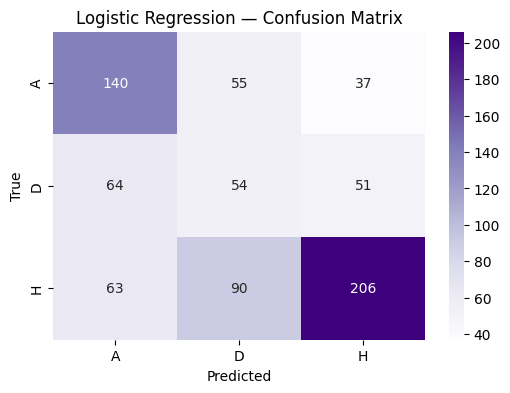

In [8]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix



# 4. Ewaluacja na teście

best_logreg = grid_logreg.best_estimator_
y_pred_clf = best_logreg.predict(X_test_clf)

acc_log_reg = accuracy_score(y_test_clf, y_pred_clf)
f1m_log_reg = f1_score(y_test_clf, y_pred_clf, average="macro")

print("\n=== Logistic Regression - TEST ===")
print(f"Accuracy:  {acc_log_reg:.4f}")
print(f"Macro-F1:  {f1m_log_reg:.4f}")

print("\n=== Classification report ===")
print(classification_report(y_test_clf, y_pred_clf, target_names=le_log.classes_))

cm = confusion_matrix(y_test_clf, y_pred_clf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=le_log.classes_, yticklabels=le_log.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression — Confusion Matrix")

save_plot("confusion_matrix_multiclass.png")
plt.show()
close_plot()

In [9]:


results.append({
    "Model": "Logistic Regression",
    "Accuracy": acc_log_reg,
    "Macro-F1": f1m_log_reg,
    "League": LEAGUE,
    "SplitDate": split_date,
    "N_train": len(y_train_clf),
    "N_test": len(y_test_clf)
})



df_results = pd.DataFrame(results)

save_df(df_results, "logistic_regression_results.csv")

print("\n===== PODSUMOWANIE MODELI LOGISTYCZNYCH =====")
display(df_results)



===== PODSUMOWANIE MODELI LOGISTYCZNYCH =====


,Model,Accuracy,Macro-F1,League,SplitDate,N_train,N_test
0,Logistic Regression,0.526316,0.495178,premier_league,2022-07-01,2660,760


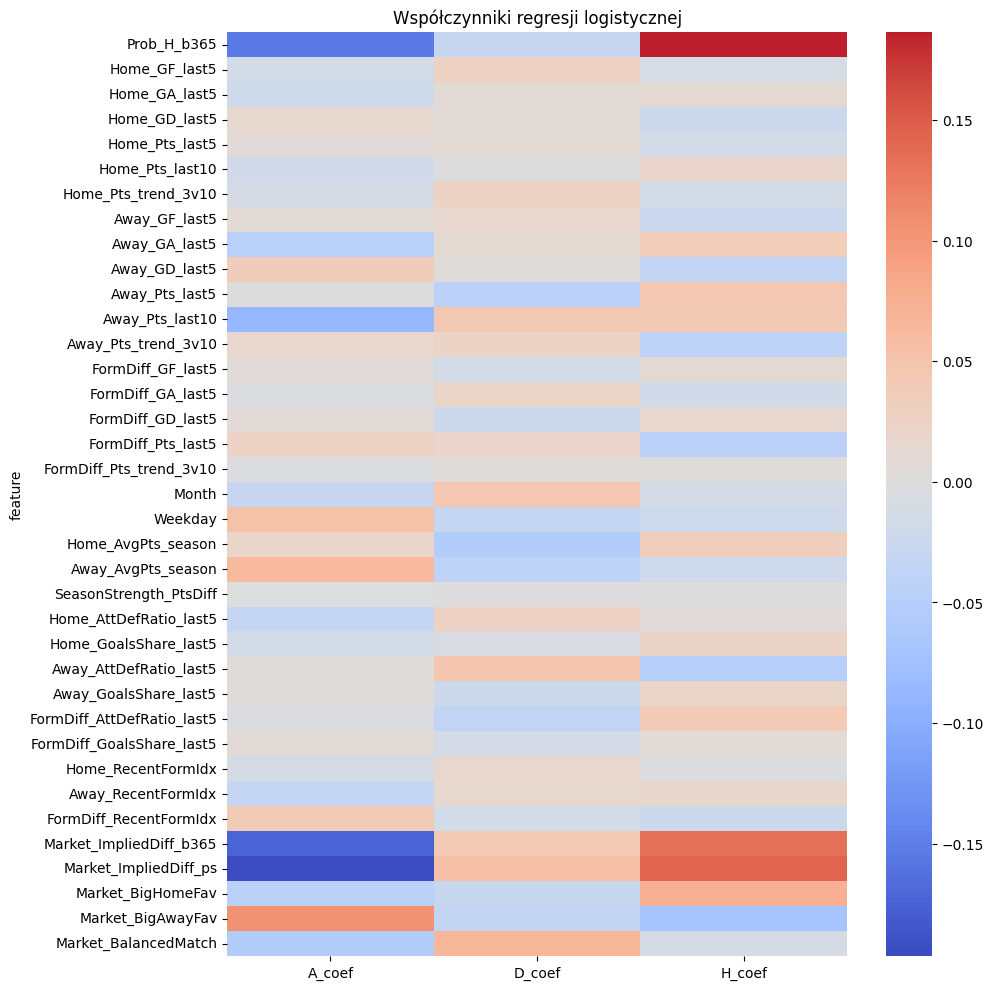

In [10]:
coeffs = best_logreg.named_steps["model"].coef_
coef_df = pd.DataFrame({
    "feature": X_train_clf.columns,
    "A_coef": coeffs[0],
    "D_coef": coeffs[1],
    "H_coef": coeffs[2]
})
coef_df["Model"] = "Logistic Regression"
coef_df["League"] = LEAGUE
save_df(coef_df, "logreg_coefficients_multiclass.csv")
coef_heatmap = (
    coef_df
    .set_index("feature")[["A_coef", "D_coef", "H_coef"]]
)

plt.figure(figsize=(10,12))
sns.heatmap(
    coef_heatmap,
    cmap="coolwarm",
    center=0
)
plt.title("Współczynniki regresji logistycznej")

save_plot("logreg_coefficients_multiclass.png")
plt.show()
close_plot()

In [11]:
report_multi = classification_report(
    y_test_clf,
    y_pred_clf,
    target_names=le_log.classes_,
    output_dict=True
)

df_report_multi = pd.DataFrame(report_multi).T
df_report_multi["Model"] = "Logistic Regression"
df_report_multi["League"] = LEAGUE

df_report_multi.to_csv(
    RESULTS_DIR / "logreg_multinomial_classification_report.csv"
)


C:\Users\tdroz\AppData\Local\Temp\ipykernel_18384\3784715287.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


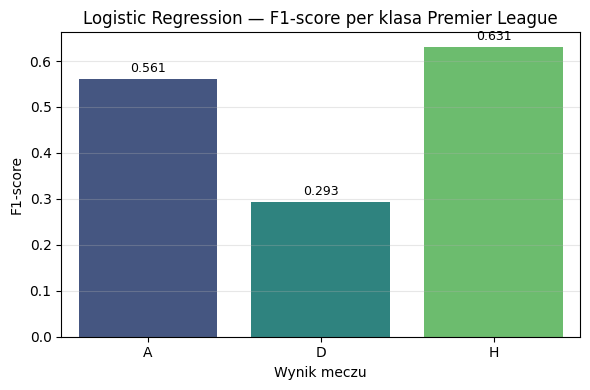

In [12]:
df_f1_class_log = (
    df_report_multi
    .loc[le_log.classes_, ["f1-score"]]
    .reset_index()
    .rename(columns={"index": "Outcome"})
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df_f1_class_log,
    x="Outcome",
    y="f1-score",
    palette="viridis"
)


for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

plt.title(f"Logistic Regression — F1-score per klasa {current_league_name}")
plt.xlabel("Wynik meczu")
plt.ylabel("F1-score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


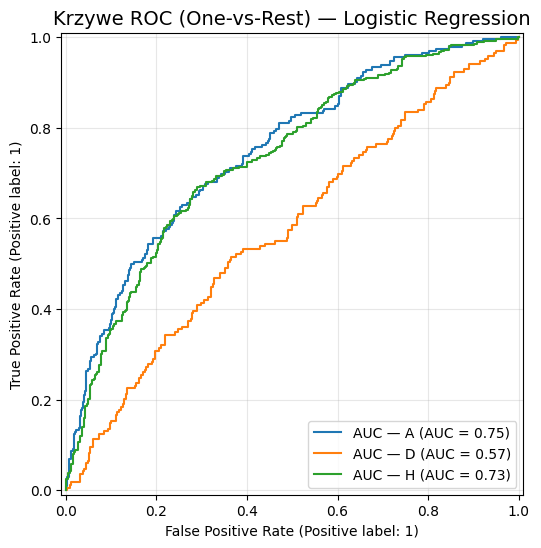

In [13]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test_clf, classes=[0, 1, 2])
y_pred_proba = best_logreg.predict_proba(X_test_clf)

fig, ax = plt.subplots(figsize=(8, 6))

for i, cls in enumerate(le_log.classes_):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_pred_proba[:, i],
        ax=ax,                      
        name=f"AUC — {cls}"
    )

ax.set_title(
    "Krzywe ROC (One-vs-Rest) — Logistic Regression",
    fontsize=14
)

ax.grid(alpha=0.3)

save_plot("roc_curves_multiclass.png")
plt.show()
close_plot()

## P(H) vs rzeczywisty GoalDiff

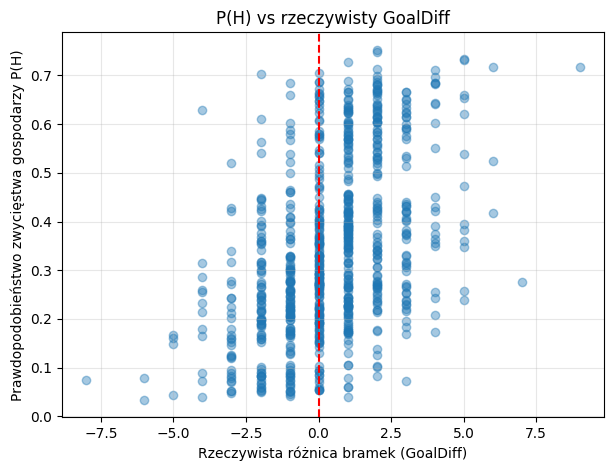

In [14]:


df["GoalDiff"] = df["FTHG"] - df["FTAG"]
true_goaldiff = df.loc[test_mask, "GoalDiff"].values

idx_H = list(le_log.classes_).index("H")
p_home = y_pred_proba[:, idx_H]

plt.figure(figsize=(7,5))
plt.scatter(true_goaldiff, p_home, alpha=0.4)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Rzeczywista różnica bramek (GoalDiff)")
plt.ylabel("Prawdopodobieństwo zwycięstwa gospodarzy P(H)")
plt.title("P(H) vs rzeczywisty GoalDiff")
plt.grid(alpha=0.3)

save_plot("p(h)_vs_goal_diff.png")
plt.show()
close_plot()


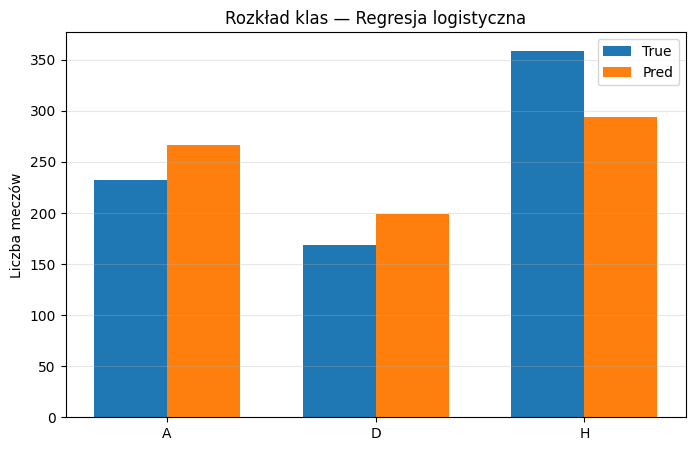

,Class,True_Count,Pred_Count
0,A,232,267
1,D,169,199
2,H,359,294


In [15]:

y_true_cls = le_log.inverse_transform(y_test_clf)
y_pred_cls = le_log.inverse_transform(y_pred_clf)

plot_and_save_class_distribution(
    y_true_cls=y_true_cls,
    y_pred_cls=y_pred_cls,
    option_suffix="Regresja logistyczna",
    filename_prefix="class_distribution"
)

,Metric,Baseline_HomeWin,Logistic_Regression,Gain_vs_Baseline
0,Accuracy,0.472368,0.526316,0.053947
1,Macro-F1,0.213881,0.495178,0.281297


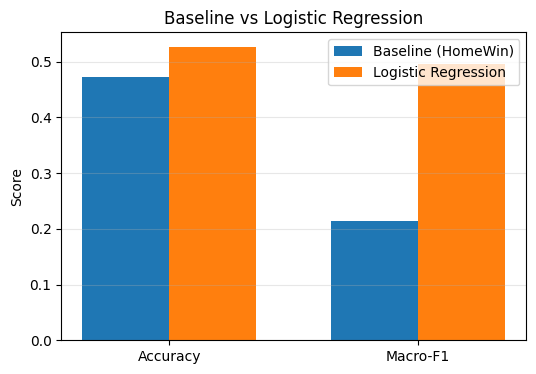

In [16]:

# BASELINE (HomeWin) vs LOGISTIC REGRESSION


y_true_cls = le_log.inverse_transform(y_test_clf)


y_naive = ["H"] * len(y_true_cls)

acc_naive = accuracy_score(y_true_cls, y_naive)
f1_naive  = f1_score(y_true_cls, y_naive, average="macro")


y_pred_cls = le_log.inverse_transform(y_pred_clf)

acc_model = accuracy_score(y_true_cls, y_pred_cls)
f1_model  = f1_score(y_true_cls, y_pred_cls, average="macro")

# --- tabela ---
df_baseline_compare = pd.DataFrame({
    "Metric": ["Accuracy", "Macro-F1"],
    "Baseline_HomeWin": [acc_naive, f1_naive],
    "Logistic_Regression": [acc_model, f1_model],
    "Gain_vs_Baseline": [
        acc_model - acc_naive,
        f1_model - f1_naive
    ]
})

display(df_baseline_compare)

save_df(
    df_baseline_compare,
    "baseline_vs_logistic_regression_multiclass.csv"
)


plt.figure(figsize=(6,4))

x = np.arange(2)
width = 0.35

plt.bar(x - width/2, [acc_naive, f1_naive],
        width, label="Baseline (HomeWin)")
plt.bar(x + width/2, [acc_model, f1_model],
        width, label="Logistic Regression")

plt.xticks(x, ["Accuracy", "Macro-F1"])
plt.ylabel("Score")
plt.title("Baseline vs Logistic Regression")
plt.legend()
plt.grid(axis="y", alpha=0.3)

save_plot("baseline_vs_logistic_regression_multiclass.png")
plt.show()
close_plot()


C:\Users\tdroz\AppData\Local\Temp\ipykernel_18384\1458867118.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))


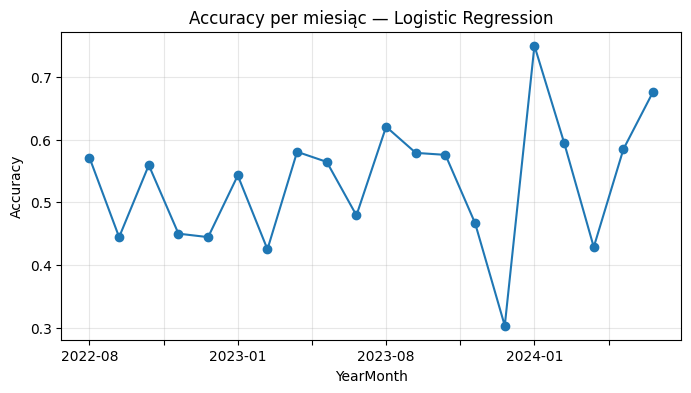

In [17]:
# Accucary per miesiąc
MIN_MATCHES = 10 
y_pred_cls = le_log.inverse_transform(y_pred_clf)
y_true_cls = le_log.inverse_transform(y_test_clf)

df_eval = df.loc[test_mask, ["Season", "Date"]].copy()
df_eval["y_true"] = y_true_cls
df_eval["y_pred"] = y_pred_cls
df_eval["YearMonth"] = df_eval["Date"].dt.to_period("M").astype(str)



acc_per_month = (
    df_eval
    .groupby("YearMonth")
    .filter(lambda x: len(x) >= MIN_MATCHES)
    .groupby("YearMonth")
    .apply(lambda x: accuracy_score(x["y_true"], x["y_pred"]))
)
df_acc_logistic = (
    acc_per_month
    .reset_index()
    .rename(columns={0: "Accuracy"})
)
df_acc_logistic["Model"] = "Logistic Regression"

df_acc_logistic.to_csv(
    RESULTS_DIR / "accuracy_per_month_logistic.csv",
    index=False
)

plt.figure(figsize=(8,4))
acc_per_month.plot(marker="o")
plt.ylabel("Accuracy")
plt.title("Accuracy per miesiąc — Logistic Regression")
plt.grid(alpha=0.3)

save_plot("accuracy_per_month_logistic.png")
plt.show()
close_plot()

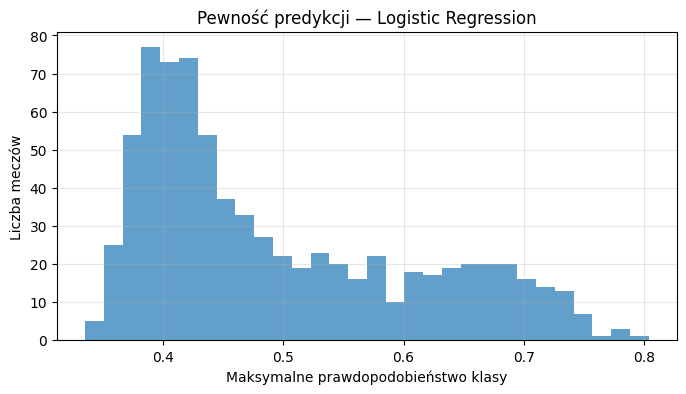

In [18]:

# Histogram pewności predykcji

max_proba = y_pred_proba.max(axis=1)

plt.figure(figsize=(8,4))
plt.hist(max_proba, bins=30, alpha=0.7)
plt.xlabel("Maksymalne prawdopodobieństwo klasy")
plt.ylabel("Liczba meczów")
plt.title("Pewność predykcji — Logistic Regression")
plt.grid(alpha=0.3)
save_plot("histogram_predicted.png")
plt.show()
close_plot()


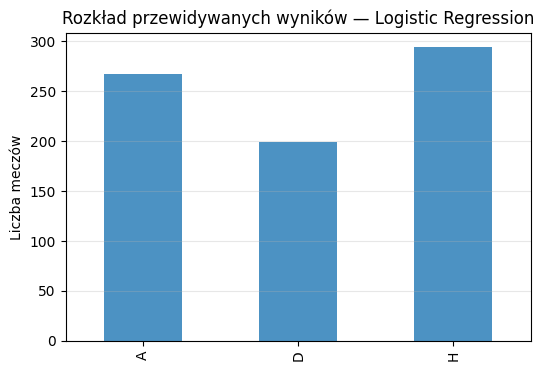

In [19]:
# Rozkład przewidywanych klas

pred_labels = pd.Series(le_log.inverse_transform(y_pred_clf))

plt.figure(figsize=(6,4))
pred_labels.value_counts().reindex(["A","D","H"]).plot(kind="bar", alpha=0.8)
plt.ylabel("Liczba meczów")
plt.title("Rozkład przewidywanych wyników — Logistic Regression")
plt.grid(axis="y", alpha=0.3)
save_plot("predicted_class_distribution.png")
plt.show()
close_plot()


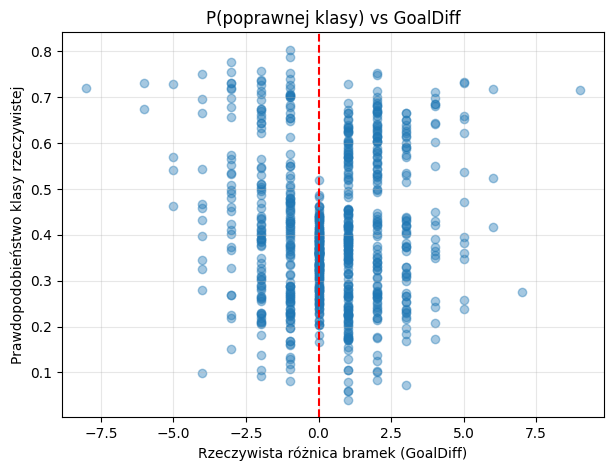

In [20]:

# P(poprawnej klasy) vs rzeczywisty GoalDiff
p_correct = y_pred_proba[np.arange(len(y_pred_proba)), y_test_clf]

plt.figure(figsize=(7,5))
plt.scatter(true_goaldiff, p_correct, alpha=0.4)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Rzeczywista różnica bramek (GoalDiff)")
plt.ylabel("Prawdopodobieństwo klasy rzeczywistej")
plt.title("P(poprawnej klasy) vs GoalDiff")
plt.grid(alpha=0.3)
save_plot("p_correct_class_vs_goal_diff.png")
plt.show()
close_plot()


# REGERSJA LOGISTYCZNA MODEL BINARNY

In [21]:

#  LOGISTIC REGRESSION - OPCJA BINARNA
#  H = 1,  A/D = 0

# 1. Binarne kodowanie celu

df_bin = df.copy()
df_bin["FTR_bin"] = df_bin["FTR"].map({"H": 1, "D": 0, "A": 0})

y_bin = df_bin["FTR_bin"].values
X_bin = df_bin[X_features].copy()


# 2. Podział train / test


split_date = pd.Timestamp("2022-07-01")
train_mask = df_bin["Date"] < split_date
test_mask  = df_bin["Date"] >= split_date

X_train_bin = X_bin.loc[train_mask].reset_index(drop=True)
X_test_bin  = X_bin.loc[test_mask].reset_index(drop=True)
y_train_bin = y_bin[train_mask]
y_test_bin  = y_bin[test_mask]

print("Train:", X_train_bin.shape, " Test:", X_test_bin.shape)

Train: (2660, 37)  Test: (760, 37)


In [22]:

# 3. Pipeline + GridSearch
results_bin = []
logreg_bin = LogisticRegression(
    class_weight="balanced",
    max_iter=2000
)
pipe_logreg_bin = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", logreg_bin)
])
param_grid = {
    "model__C": [2, 4, 6, 8, 10]
}
grid_logreg_bin = GridSearchCV(
    estimator=pipe_logreg_bin,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

print("Trenowanie GridSearchCV ")
grid_logreg_bin.fit(X_train_bin, y_train_bin)

print("Najlepsze parametry:", grid_logreg_bin.best_params_)
print("Najlepszy wynik CV (Macro-F1):", grid_logreg_bin.best_score_)

Trenowanie GridSearchCV 
Najlepsze parametry: {'model__C': 6}
Najlepszy wynik CV (Macro-F1): 0.6693628128902702


In [23]:

# 4. Wyniki na teście

best_logreg_bin = grid_logreg_bin.best_estimator_
y_pred = best_logreg_bin.predict(X_test_bin)
acc_bin = accuracy_score(y_test_bin, y_pred)
f1_bin = f1_score(y_test_bin, y_pred)

print("\n=== Logistic Regression (Binary) - TEST ===")
print("Accuracy:", round(acc_bin, 4))
print("F1:", round(f1_bin, 4))

print("\n=== Classification report ===")
print(classification_report(
    y_test_bin, y_pred, target_names=["NoHomeWin (A/D)", "HomeWin (H)"])
)


=== Logistic Regression (Binary) - TEST ===
Accuracy: 0.6816
F1: 0.6685

=== Classification report ===
                 precision    recall  f1-score   support

NoHomeWin (A/D)       0.70      0.68      0.69       401
    HomeWin (H)       0.66      0.68      0.67       359

       accuracy                           0.68       760
      macro avg       0.68      0.68      0.68       760
   weighted avg       0.68      0.68      0.68       760



In [24]:
results_bin.append({
    "Model": "Logistic Regression (Binary HomeWin)",
    "Accuracy": acc_bin,
    "Macro-F1": f1_bin,   
    "League": LEAGUE,
    "SplitDate": split_date,
    "N_train": len(y_train_bin),
    "N_test": len(y_test_bin)
})


df_results_bin = pd.DataFrame(results_bin)

save_df(df_results_bin, "logistic_regression_bin_results.csv")

print("\n===== PODSUMOWANIE MODELI LOGISTYCZNYCH =====")
display(df_results_bin)


===== PODSUMOWANIE MODELI LOGISTYCZNYCH =====


,Model,Accuracy,Macro-F1,League,SplitDate,N_train,N_test
0,Logistic Regression (Binary HomeWin),0.681579,0.668493,premier_league,2022-07-01,2660,760


In [25]:
report_bin = classification_report(
    y_test_bin,
    y_pred,
    target_names=["NoHomeWin (A/D)", "HomeWin (H)"],
    output_dict=True
)

df_report_bin = pd.DataFrame(report_bin).T
df_report_bin["Model"] = "Logistic Regression (Binary)"
df_report_bin["League"] = LEAGUE

df_report_bin.to_csv(
    RESULTS_DIR / "logreg_binary_classification_report.csv",
    index=True
)

df_report_bin

,precision,recall,f1-score,support,Model,League
NoHomeWin (A/D),0.704370,0.683292,0.693671,401.000000,Logistic Regression (Binary),premier_league
HomeWin (H),0.657682,0.679666,0.668493,359.000000,Logistic Regression (Binary),premier_league
accuracy,0.681579,0.681579,0.681579,0.681579,Logistic Regression (Binary),premier_league
macro avg,0.681026,0.681479,0.681082,760.000000,Logistic Regression (Binary),premier_league
weighted avg,0.682316,0.681579,0.681778,760.000000,Logistic Regression (Binary),premier_league


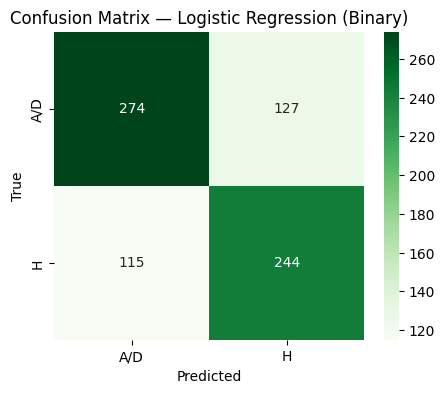

In [26]:

# 5. Confusion Matrix


cm_bin = confusion_matrix(y_test_bin, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_bin, annot=True, fmt="d", cmap="Greens",
            xticklabels=["A/D","H"], yticklabels=["A/D","H"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Logistic Regression (Binary)")

save_plot("confusion_matrix_binary.png")
plt.show()
close_plot()